In [177]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Online Retail.xlsx")
# Typage
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
print(df.head(20))
print(f"\nTaille : {df.shape}")

KeyboardInterrupt: 

In [ ]:
df = df.query("'C' not in `InvoiceNo` and `Quantity` > 0 and `UnitPrice` > 0")
print(f"\nTaille : {df.shape}")


Taille : (530104, 8)


In [ ]:
df["CustomerID"].isna().value_counts()

CustomerID
False    397884
True     132220
Name: count, dtype: int64

In [ ]:
df.dropna(subset="CustomerID", inplace=True)
print(f"\nTaille : {df.shape}")


Taille : (397884, 8)


In [ ]:
df.isna().value_counts()

InvoiceNo  StockCode  Description  Quantity  InvoiceDate  UnitPrice  CustomerID  Country
False      False      False        False     False        False      False       False      397884
Name: count, dtype: int64

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True, errors="coerce")
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


Maintenant à partir de ce jeu de données on va créer un autre jeu de données mais dans lequel les lignes seront les clients et non les transactions. On va créer facile à créer en prenant juste les moyeenes et les fréquences de chaque variable. On va pour les dates calculer la récence et l'ancieneté.

In [ ]:
frequence = df.groupby("CustomerID")["InvoiceNo"].nunique()
data = pd.DataFrame({"frequence": frequence})
data

,frequence
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,2


In [ ]:
data["nb_produit"] = df.groupby("CustomerID")["StockCode"].count()
data

,frequence,nb_produit
CustomerID,,
12346.0,1,1
12347.0,7,182
12348.0,4,31
12349.0,1,73
12350.0,1,17
...,...,...
18280.0,1,10
18281.0,1,7
18282.0,2,12


In [ ]:
data["quantité_moyenne"] = df.groupby("CustomerID")["Quantity"].mean()
data

,frequence,nb_produit,quantité_moyenne
CustomerID,,,
12346.0,1,1,74215.000000
12347.0,7,182,13.505495
12348.0,4,31,75.516129
12349.0,1,73,8.643836
12350.0,1,17,11.588235
...,...,...,...
18280.0,1,10,4.500000
18281.0,1,7,7.714286
18282.0,2,12,8.583333


In [ ]:
from datetime import timedelta

recence = (
    df["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].max()
    + timedelta(days=1)
).dt.days
data["recence"] = recence
data

,frequence,nb_produit,quantité_moyenne,recence
CustomerID,,,,
12346.0,1,1,74215.000000,326
12347.0,7,182,13.505495,2
12348.0,4,31,75.516129,75
12349.0,1,73,8.643836,19
12350.0,1,17,11.588235,310
...,...,...,...,...
18280.0,1,10,4.500000,278
18281.0,1,7,7.714286,181
18282.0,2,12,8.583333,8


In [ ]:
ancienneté = (
    df["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].min()
    + timedelta(days=1)
).dt.days
data["ancienneté"] = ancienneté
data

,frequence,nb_produit,quantité_moyenne,recence,ancienneté
CustomerID,,,,,
12346.0,1,1,74215.000000,326,326
12347.0,7,182,13.505495,2,367
12348.0,4,31,75.516129,75,358
12349.0,1,73,8.643836,19,19
12350.0,1,17,11.588235,310,310
...,...,...,...,...,...
18280.0,1,10,4.500000,278,278
18281.0,1,7,7.714286,181,181
18282.0,2,12,8.583333,8,126


In [ ]:
durée = (
    df.groupby("CustomerID")["InvoiceDate"].max()
    - df.groupby("CustomerID")["InvoiceDate"].min()
    + timedelta(days=1)
).dt.days
data["durée"] = durée
data

,frequence,nb_produit,quantité_moyenne,recence,ancienneté,durée
CustomerID,,,,,,
12346.0,1,1,74215.000000,326,326,1
12347.0,7,182,13.505495,2,367,366
12348.0,4,31,75.516129,75,358,283
12349.0,1,73,8.643836,19,19,1
12350.0,1,17,11.588235,310,310,1
...,...,...,...,...,...,...
18280.0,1,10,4.500000,278,278,1
18281.0,1,7,7.714286,181,181,1
18282.0,2,12,8.583333,8,126,119


In [ ]:
data["prix_unitaire_moyen"] = df.groupby("CustomerID")["UnitPrice"].mean()
data

,frequence,nb_produit,quantité_moyenne,recence,ancienneté,durée,prix_unitaire_moyen
CustomerID,,,,,,,
12346.0,1,1,74215.000000,326,326,1,1.040000
12347.0,7,182,13.505495,2,367,366,2.644011
12348.0,4,31,75.516129,75,358,283,5.764839
12349.0,1,73,8.643836,19,19,1,8.289041
12350.0,1,17,11.588235,310,310,1,3.841176
...,...,...,...,...,...,...,...
18280.0,1,10,4.500000,278,278,1,4.765000
18281.0,1,7,7.714286,181,181,1,5.622857
18282.0,2,12,8.583333,8,126,119,5.199167


On va partir de cette base de données pour faire notre clustering. On va d'abords regarder les distribution de chaque variables.

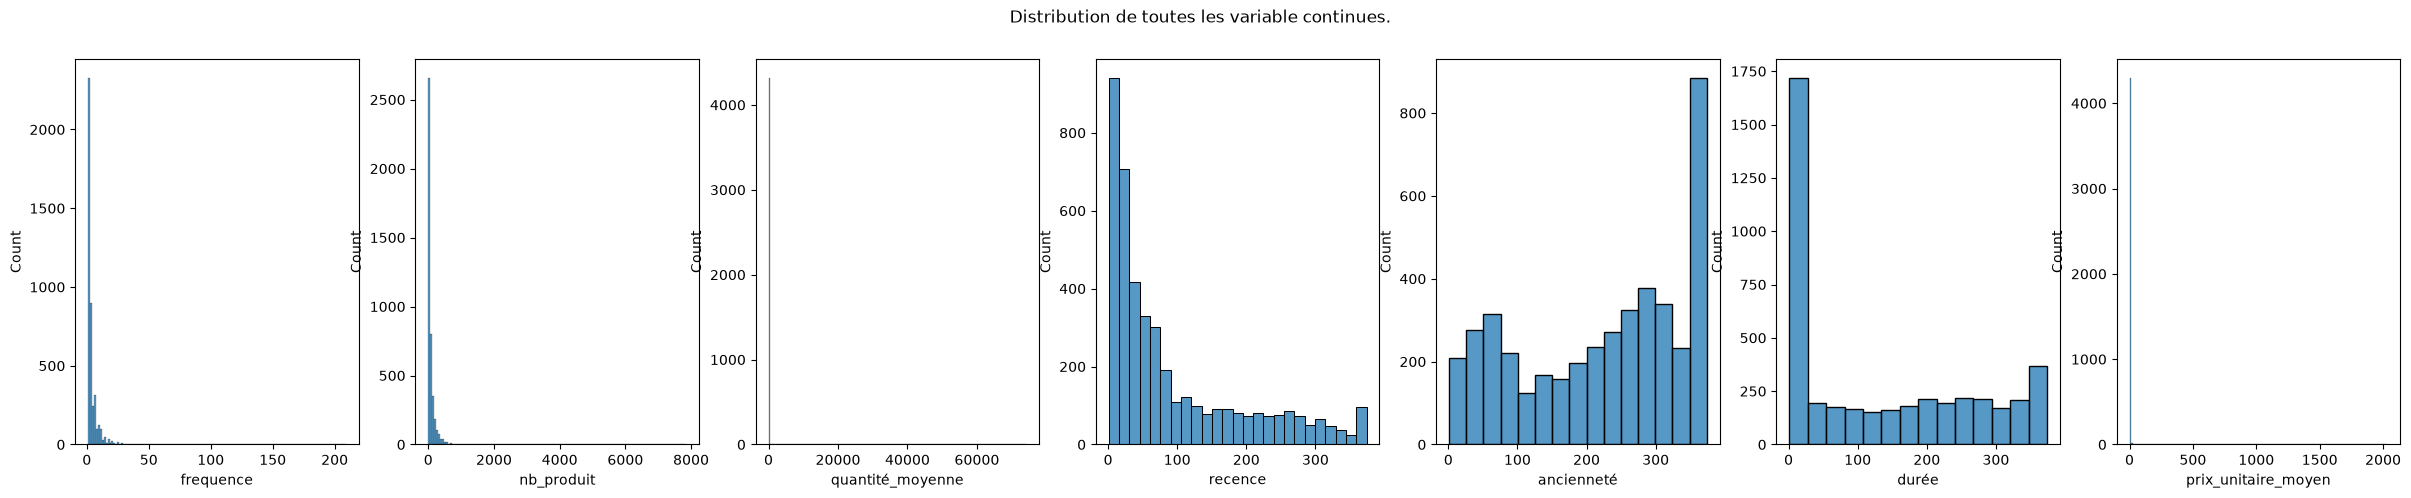

In [ ]:
import seaborn as sns

fig, ax = plt.subplots(1, 7)
fig.set_size_inches(30, 5)
plt.suptitle("Distribution de toutes les variable continues.")
sns.histplot(data, x="frequence", ax=ax[0])
sns.histplot(data, x="nb_produit", ax=ax[1])
sns.histplot(data, x="quantité_moyenne", ax=ax[2])
sns.histplot(data, x="recence", ax=ax[3])
sns.histplot(data, x="ancienneté", ax=ax[4])
sns.histplot(data, x="durée", ax=ax[5])
sns.histplot(data, x="prix_unitaire_moyen", ax=ax[6])
plt.show()

On voit que toutes les variables ne sont pas centré. On va donc appliqué un logarithme.

In [ ]:
import numpy as np

data_log = data.copy()


data_log[data_log.select_dtypes(include="number").columns] = np.log1p(
    data_log[data_log.select_dtypes(include="number").columns]
)
data_log

,frequence,nb_produit,quantité_moyenne,recence,ancienneté,durée,prix_unitaire_moyen
CustomerID,,,,,,,
12346.0,0.693147,0.693147,11.214735,5.789960,5.789960,0.693147,0.712950
12347.0,2.079442,5.209486,2.674528,1.098612,5.908083,5.905362,1.293085
12348.0,1.609438,3.465736,4.337502,4.330733,5.883322,5.648974,1.911738
12349.0,0.693147,4.304065,2.266319,2.995732,2.995732,0.693147,2.228835
12350.0,0.693147,2.890372,2.532763,5.739793,5.739793,0.693147,1.577158
...,...,...,...,...,...,...,...
18280.0,0.693147,2.397895,1.704748,5.631212,5.631212,0.693147,1.751805
18281.0,0.693147,2.079442,2.164964,5.204007,5.204007,0.693147,1.890527
18282.0,1.098612,2.564949,2.260025,2.197225,4.844187,4.787492,1.824415


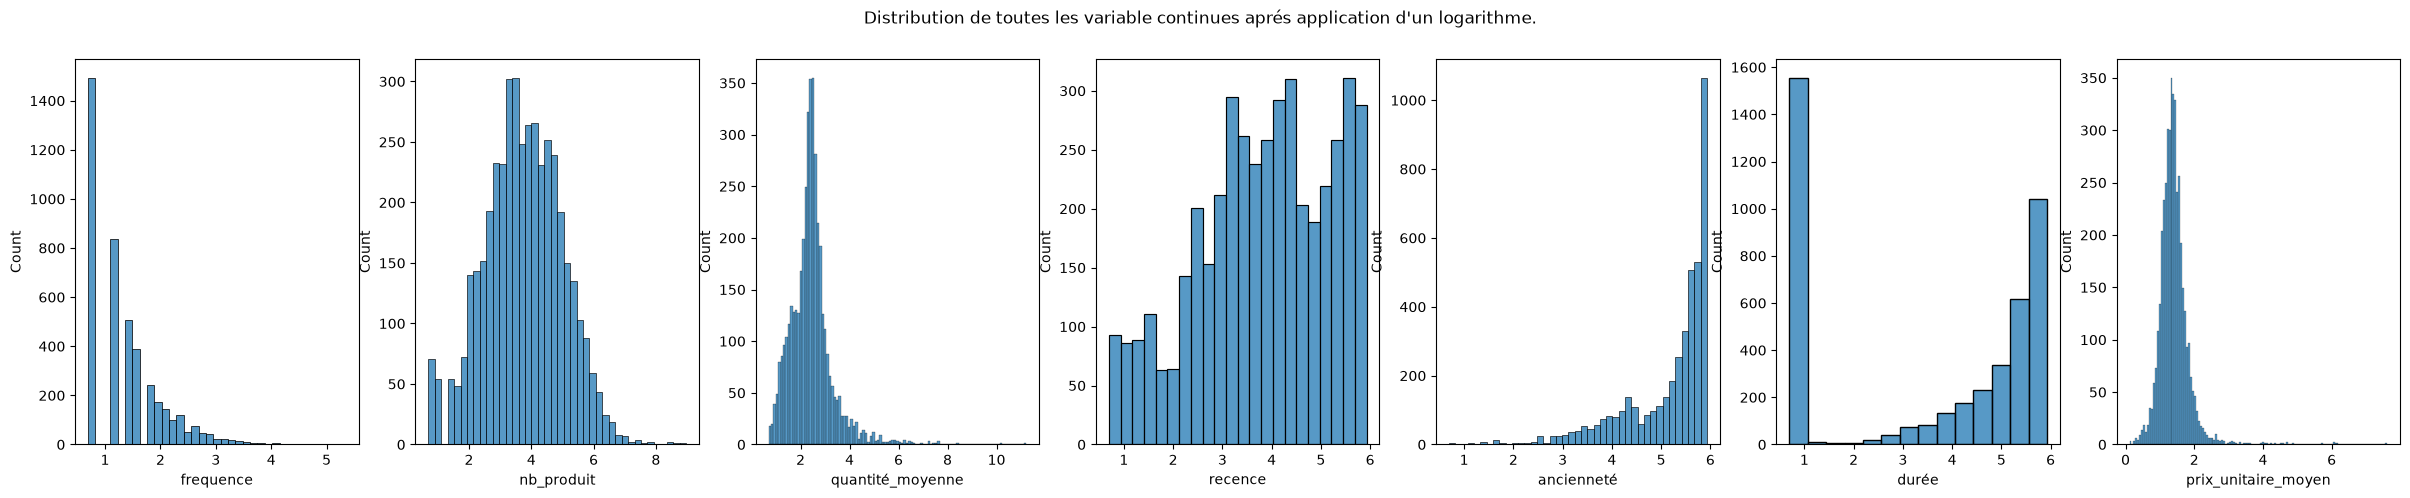

In [ ]:
fig, ax = plt.subplots(1, 7)
fig.set_size_inches(30, 5)
plt.suptitle(
    "Distribution de toutes les variable continues aprés application d'un logarithme."
)
sns.histplot(data_log, x="frequence", ax=ax[0])
sns.histplot(data_log, x="nb_produit", ax=ax[1])
sns.histplot(data_log, x="quantité_moyenne", ax=ax[2])
sns.histplot(data_log, x="recence", ax=ax[3])
sns.histplot(data_log, x="ancienneté", ax=ax[4])
sns.histplot(data_log, x="durée", ax=ax[5])
sns.histplot(data_log, x="prix_unitaire_moyen", ax=ax[6])
plt.show()

On va maintenant appliqué un onehotencoder puis un standardscaler. On gardera les pays ayant minimum 30 points. Les autres seront mis dans les autres.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn import set_config

set_config(transform_output="pandas")

data_finale = StandardScaler().fit_transform(data_log)
data_finale

,frequence,nb_produit,quantité_moyenne,recence,ancienneté,durée,prix_unitaire_moyen
CustomerID,,,,,,,
12346.0,-0.955214,-2.434387,10.199999,1.461993,0.720304,-1.269067,-1.575836
12347.0,1.074425,1.177483,0.285845,-2.038734,0.853805,1.088702,-0.247046
12348.0,0.386304,-0.217054,2.216358,0.373104,0.825821,0.972723,1.169970
12349.0,-0.955214,0.453387,-0.188036,-0.623086,-2.437686,-1.269067,1.896276
12350.0,-0.955214,-0.677192,0.121273,1.424558,0.663606,-1.269067,0.403619
...,...,...,...,...,...,...,...
18280.0,-0.955214,-1.071042,-0.839953,1.343533,0.540889,-1.269067,0.803646
18281.0,-0.955214,-1.325720,-0.305698,1.024749,0.058069,-1.269067,1.121385
18282.0,-0.361583,-0.937443,-0.195342,-1.218940,-0.348593,0.583028,0.969957


On va maintenant faire une pca.

In [ ]:
from sklearn.decomposition import PCA

data_pca = PCA(n_components=2, random_state=42).fit_transform(data_log)
data_pca

,pca0,pca1
CustomerID,,
12346.0,-4.115156,2.468661
12347.0,3.701620,-1.292053
12348.0,1.690949,1.657972
12349.0,-2.350728,-2.670497
12350.0,-3.302869,1.145926
...,...,...
18280.0,-3.464900,1.035625
18281.0,-3.513681,0.603162
18282.0,1.061349,-0.775245


<Axes: xlabel='pca0', ylabel='pca1'>

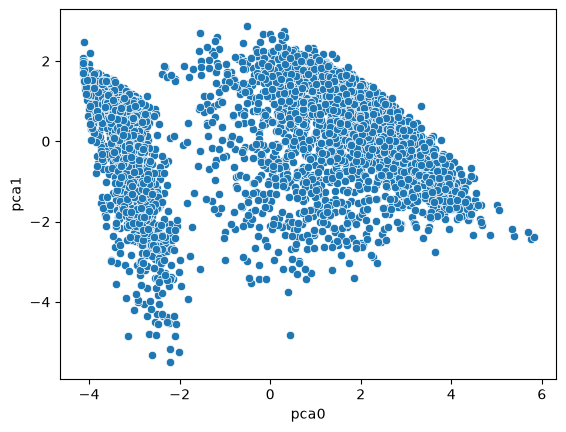

In [ ]:
sns.scatterplot(data_pca, x="pca0", y="pca1")

<Axes: xlabel='pca0', ylabel='pca1'>

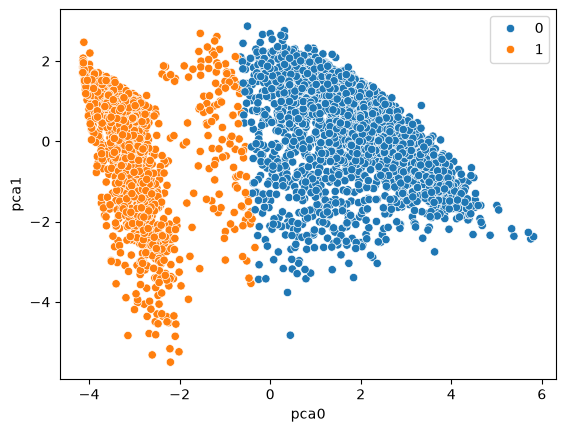

In [ ]:
from sklearn.cluster import KMeans, SpectralClustering

cluster = KMeans(n_clusters=2, random_state=42).fit_predict(data_pca)
sns.scatterplot(data_pca, x="pca0", y="pca1", hue=cluster)

<Axes: xlabel='pca0', ylabel='pca1'>

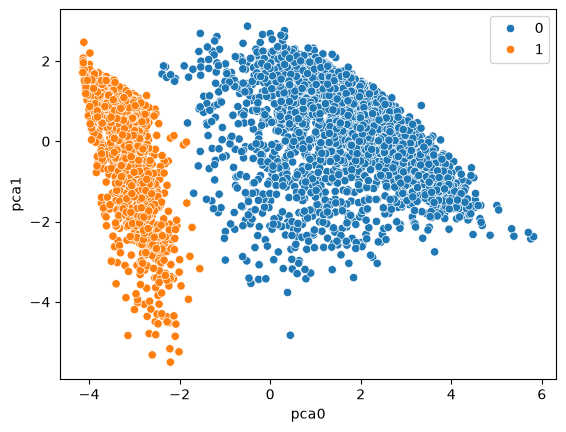

In [ ]:
cluster_spectral = SpectralClustering(
    n_clusters=2, random_state=42, gamma=10
).fit_predict(data_pca)

sns.scatterplot(data_pca, x="pca0", y="pca1", hue=cluster_spectral)

On arrive à clairement séparer deux cluster. Maintenant il faut rajouter de l'information pour séparer le troisiéme.